#  Twitter Sentiment Analysis

## Week 1 - Data Loading & Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to load the Twitter dataset, understand its structure, perform initial data cleaning, and explore the distribution of sentiment labels before text preprocessing.

### Tasks Covered

- Import required libraries
- Download NLP resources
- Load dataset
- Explore dataset
- Check missing values
- Remove duplicates
- Select useful columns
- Analyze sentiment distribution
- Visualize dataset

In [47]:
# ================================================
# IMPORT LIBRARIES
# ================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

# Download required NLTK data (only needs to run once per environment)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')  # newer NLTK versions (3.8+) split punkt into punkt_tab

# Display plots inside notebook
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 📥 Download NLTK Resources

Natural Language Toolkit (NLTK) provides useful resources required for text preprocessing such as stopwords, tokenizers, and lemmatization dictionaries.

In [48]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kirti\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##  Load the Twitter Dataset

The dataset is loaded into a Pandas DataFrame for preprocessing and analysis.

In [49]:
df = pd.read_csv("../dataset/Tweets.csv")

##  Display the First Five Records

Displaying the first few rows helps us understand the structure of the dataset and inspect the available features.

In [50]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


##  Dataset Dimensions

This section displays the total number of rows and columns available in the dataset.

In [51]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 14640
Number of Columns : 15


##  Display Column Names

The dataset contains several columns. We first inspect all available features before selecting the important ones.

In [52]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

##  Dataset Information

The `info()` function provides details about:

- Data types
- Number of non-null values
- Memory usage

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

##  Check Missing Values

Machine learning models require clean datasets. This step identifies missing values in each column.

In [54]:
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

##  Select Required Features

For sentiment classification, only two columns are required:

- Tweet Text
- Sentiment Label

All other columns are removed.

In [55]:
df = df[['text','airline_sentiment']]

##  Rename Columns

The column names are renamed to make them shorter and easier to use throughout the project.

In [56]:
df.columns = ['tweet','sentiment']

##  View Updated Dataset

Display the updated dataset after selecting and renaming the required columns.

In [57]:
df.head()

,tweet,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


##  Handle Missing Values

Any rows containing missing values are removed to ensure data quality.

In [58]:
print(df.isnull().sum())

df.dropna(inplace=True)

print(df.isnull().sum())

tweet        0
sentiment    0
dtype: int64
tweet        0
sentiment    0
dtype: int64


##  Check Duplicate Tweets

Duplicate records may bias the model during training.

This section identifies and removes duplicate tweets.

In [59]:
print("Duplicate Tweets :", df.duplicated().sum())

Duplicate Tweets : 188


## Remove Duplicate Records

Duplicate tweets are removed to improve data quality.

In [60]:
df.drop_duplicates(inplace=True)

print("Remaining Duplicate Tweets :", df.duplicated().sum())

Remaining Duplicate Tweets : 0


## 😊 Sentiment Distribution

Let's examine the number of tweets belonging to each sentiment category.

In [61]:
df['sentiment'].value_counts()

sentiment
negative    9087
neutral     3067
positive    2298
Name: count, dtype: int64

##  Visualize Sentiment Distribution

A count plot is generated to visualize the distribution of positive, neutral, and negative tweets.

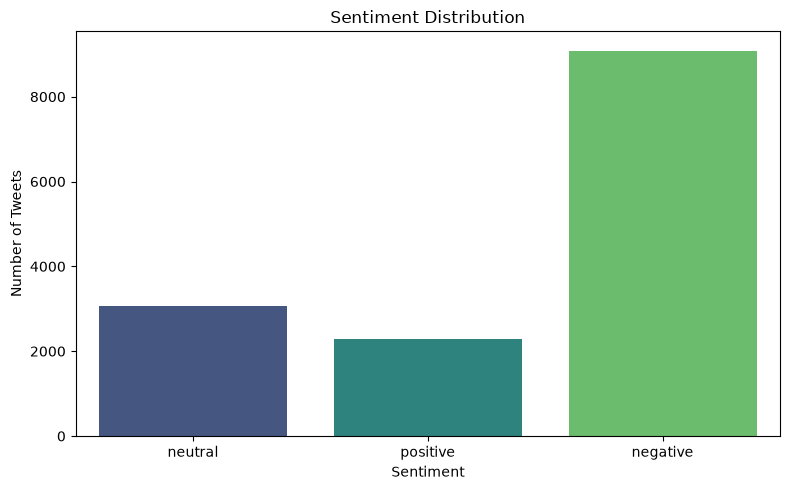

In [88]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiment",
    hue="sentiment",
    palette="viridis",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.tight_layout()

plt.savefig("../images/sentiment_distribution.png", dpi=300)

plt.show()
plt.close()


## Generate Word Cloud

A Word Cloud provides a visual representation of the most frequently occurring words in the tweets.

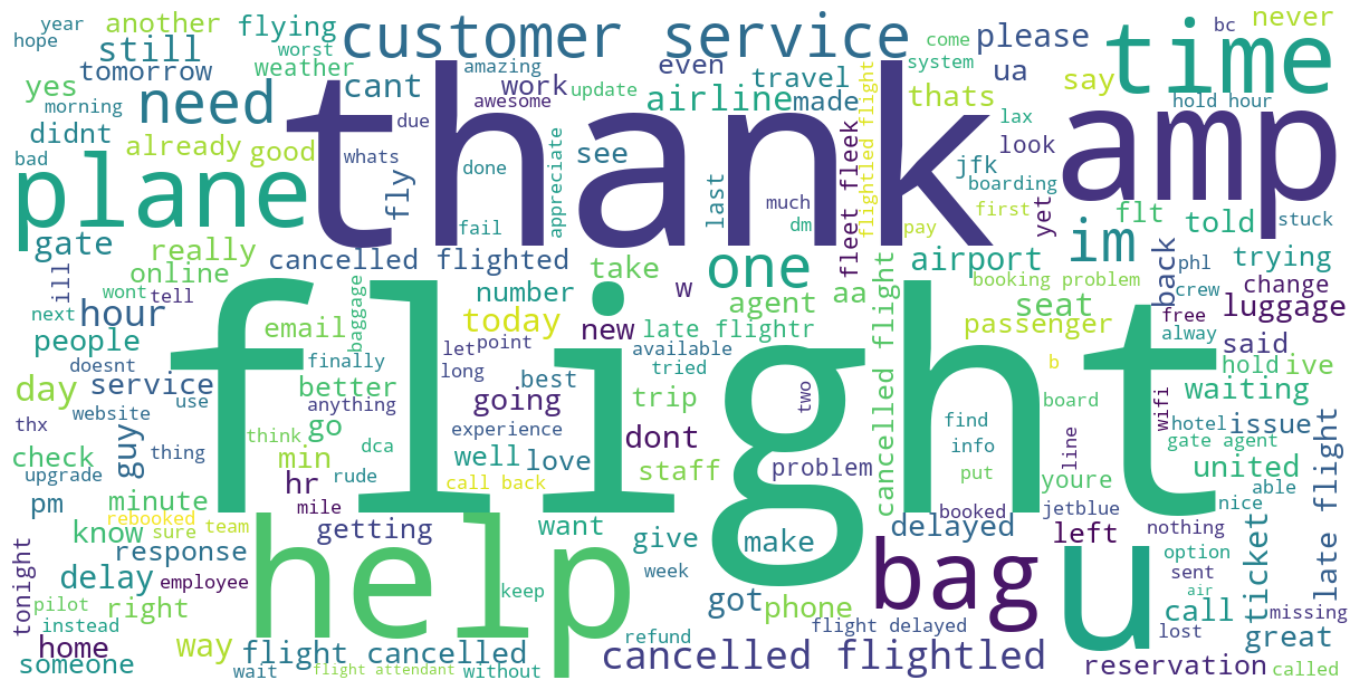

In [89]:
text = " ".join(df["clean_tweet"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.tight_layout()

plt.savefig("../images/wordcloud.png", dpi=300)

plt.show()
plt.close()

#  Text Preprocessing Using Regular Expressions (Regex)

## Objective

Raw tweets often contain unnecessary information such as:

- URLs
- User mentions (@username)
- Hashtags (#topic)
- Numbers
- Punctuation
- Extra whitespaces

These elements do not contribute significantly to sentiment analysis and may reduce model performance.

In this section, we clean the tweet text using Python Regular Expressions (Regex).

In [66]:
# Create a copy of original tweets

df["clean_tweet"] = df["tweet"]

##  Convert Tweets to Lowercase

Converting all text to lowercase ensures that words such as:

- Good
- GOOD
- good

are treated as the same word during preprocessing.

In [67]:
df["clean_tweet"] = df["clean_tweet"].str.lower()

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


##  Remove URLs

Tweets frequently contain hyperlinks.

Example:

https://twitter.com

These URLs do not provide useful sentiment information and are removed using Regular Expressions.

In [68]:
df["clean_tweet"] = df["clean_tweet"].str.replace(
    r"http\S+|www\S+|https\S+",
    "",
    regex=True
)

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,@virginamerica what @dhepburn said.
1,@VirginAmerica plus you've added commercials t...,@virginamerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...,@virginamerica i didn't today... must mean i n...
3,@VirginAmerica it's really aggressive to blast...,@virginamerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...,@virginamerica and it's a really big bad thing...


##  Remove User Mentions

Twitter usernames begin with the **@** symbol.

Example:

@United

These mentions identify users rather than expressing sentiment, so they are removed.

In [69]:
df["clean_tweet"] = df["clean_tweet"].str.replace(
    r"@\w+",
    "",
    regex=True
)

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


## #️ Remove Hashtags

Hashtags usually begin with the **#** symbol.

Example:

#Travel

The hashtag symbol is removed while retaining the associated word whenever possible.

In [70]:
df["clean_tweet"] = df["clean_tweet"].str.replace(
    "#",
    "",
    regex=False
)

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


##  Remove Numbers

Numbers generally do not contribute meaningful information for sentiment classification.

Example:

Flight 123

becomes

Flight

In [71]:
df["clean_tweet"] = df["clean_tweet"].str.replace(
    r"\d+",
    "",
    regex=True
)

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said.
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials to the experien...
2,@VirginAmerica I didn't today... Must mean I n...,i didn't today... must mean i need to take an...
3,@VirginAmerica it's really aggressive to blast...,"it's really aggressive to blast obnoxious ""en..."
4,@VirginAmerica and it's a really big bad thing...,and it's a really big bad thing about it


##  Remove Punctuation

Punctuation marks such as:

- !
- ?
- .
- ,
- :

are removed to simplify the text before tokenization.

In [72]:
import string

df["clean_tweet"] = df["clean_tweet"].str.translate(
    str.maketrans('', '', string.punctuation)
)

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


##  Remove Extra Whitespaces

After cleaning, multiple spaces may remain.

This step replaces multiple spaces with a single space and removes leading/trailing spaces.

In [73]:
df["clean_tweet"] = df["clean_tweet"].str.replace(
    r"\s+",
    " ",
    regex=True
).str.strip()

df[["tweet","clean_tweet"]].head()

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


##  Cleaned Tweet Sample

The following table compares the original tweet with its cleaned version after applying Regular Expression (Regex) preprocessing.

In [74]:
df[["tweet","clean_tweet"]].head(10)

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this “ear worm”...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didnt…but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early youre...


#  Tokenization

## Objective

Tokenization is the process of splitting a sentence into individual words (tokens).

Example:

Original:

I love this airline.

Tokens:

["I", "love", "this", "airline"]

In [75]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["clean_tweet"].apply(word_tokenize)

df[["clean_tweet","tokens"]].head()

,clean_tweet,tokens
0,what said,"[what, said]"
1,plus youve added commercials to the experience...,"[plus, youve, added, commercials, to, the, exp..."
2,i didnt today must mean i need to take another...,"[i, didnt, today, must, mean, i, need, to, tak..."
3,its really aggressive to blast obnoxious enter...,"[its, really, aggressive, to, blast, obnoxious..."
4,and its a really big bad thing about it,"[and, its, a, really, big, bad, thing, about, it]"


#  Stopword Removal

Stopwords are very common words that usually carry little semantic meaning.

Examples include:

- the
- is
- are
- and
- was

Removing stopwords helps the model focus on more informative words.

In [76]:
stop_words = set(stopwords.words("english"))

df["tokens"] = df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df[["clean_tweet","tokens"]].head()

,clean_tweet,tokens
0,what said,[said]
1,plus youve added commercials to the experience...,"[plus, youve, added, commercials, experience, ..."
2,i didnt today must mean i need to take another...,"[didnt, today, must, mean, need, take, another..."
3,its really aggressive to blast obnoxious enter...,"[really, aggressive, blast, obnoxious, enterta..."
4,and its a really big bad thing about it,"[really, big, bad, thing]"


#  Lemmatization

## Objective

Lemmatization converts words to their base (dictionary) form.

Examples:

- flying → fly
- delayed → delay
- flights → flight

This reduces vocabulary size and improves model performance.

In [77]:
lemmatizer = WordNetLemmatizer()

df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[["clean_tweet","tokens"]].head()

,clean_tweet,tokens
0,what said,[said]
1,plus youve added commercials to the experience...,"[plus, youve, added, commercial, experience, t..."
2,i didnt today must mean i need to take another...,"[didnt, today, must, mean, need, take, another..."
3,its really aggressive to blast obnoxious enter...,"[really, aggressive, blast, obnoxious, enterta..."
4,and its a really big bad thing about it,"[really, big, bad, thing]"


##  Convert Tokens Back to Sentences

Machine learning models generally require text rather than lists of words.

This step joins the processed tokens into cleaned sentences.

In [78]:
df["clean_tweet"] = df["tokens"].apply(lambda words: " ".join(words))

df[["tweet","clean_tweet"]].head(10)

,tweet,clean_tweet
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx “ ear worm ” ’ go...
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well didnt…but
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early youre good


#  Word Cloud for Positive Tweets

## Objective

A Word Cloud is generated using only the tweets labeled as **Positive**.

This visualization highlights the words that appear most frequently in positive customer feedback and helps identify common themes associated with positive sentiment.

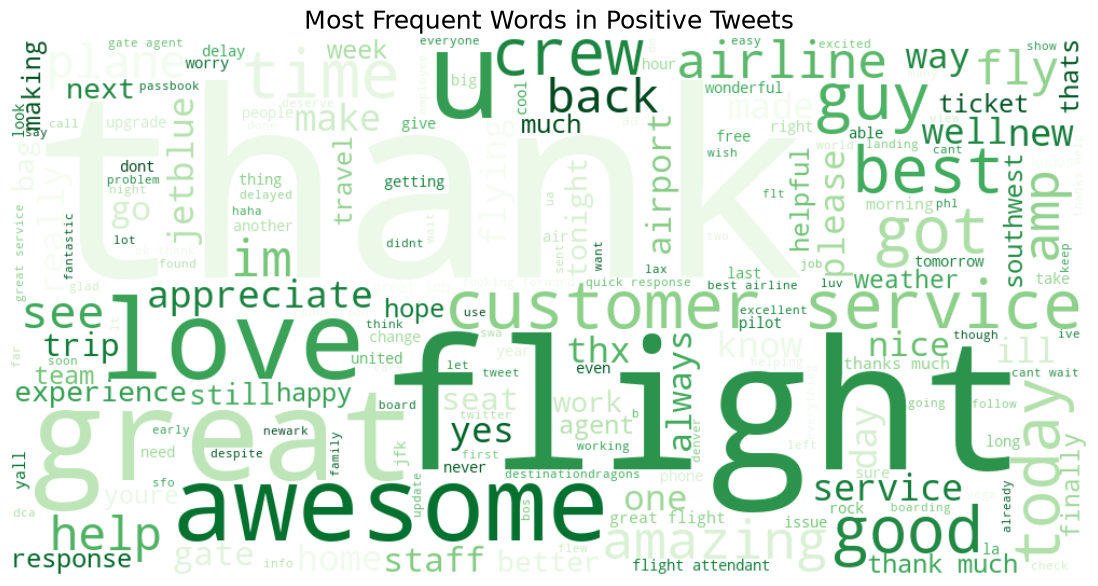

In [79]:
# Extract positive tweets
positive_tweets = " ".join(
    df[df["sentiment"] == "positive"]["clean_tweet"]
)

# Generate Word Cloud
positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Greens"
).generate(positive_tweets)

# Display
plt.figure(figsize=(15,7))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Positive Tweets", fontsize=18)
plt.show()

In [80]:
positive_wc.to_file("../images/positive_wordcloud.png")

#  Word Cloud for Negative Tweets

## Objective

This Word Cloud visualizes the most frequently occurring words in **Negative** tweets.

Analyzing these words helps identify the common reasons behind customer dissatisfaction.

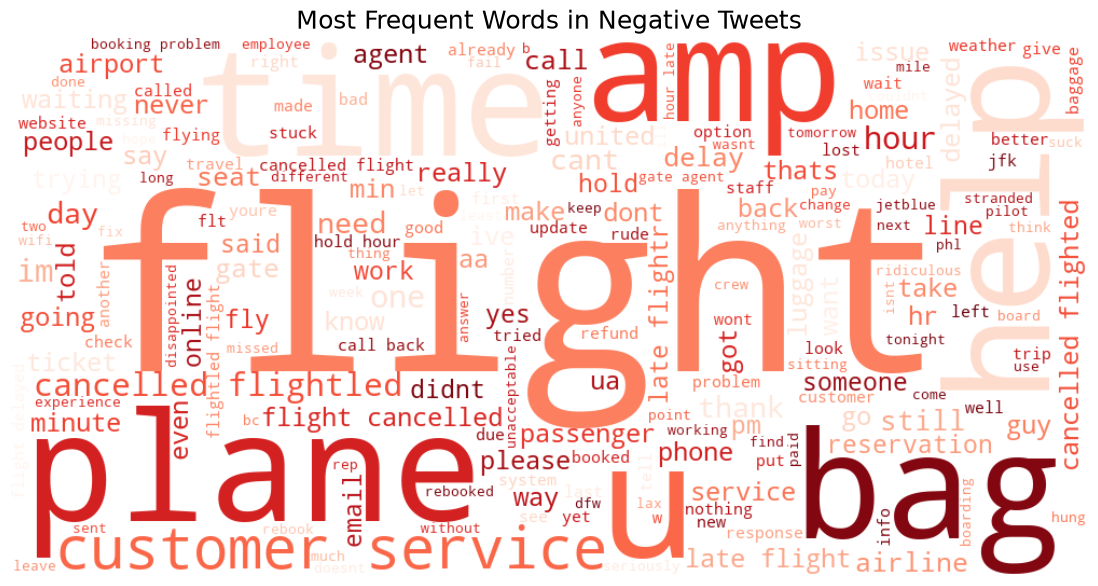

In [81]:
# Extract negative tweets
negative_tweets = " ".join(
    df[df["sentiment"] == "negative"]["clean_tweet"]
)

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Reds"
).generate(negative_tweets)

plt.figure(figsize=(15,7))
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Negative Tweets", fontsize=18)
plt.show()

In [82]:
negative_wc.to_file("../images/negative_wordcloud.png")

#  Compare Positive and Negative Word Frequency

The two Word Clouds reveal the most frequently occurring words in positive and negative customer tweets.

### Positive Tweets

Generally contain words related to:

- appreciation
- satisfaction
- thanks
- great
- love

### Negative Tweets

Generally contain words related to:

- delay
- cancelled
- customer service
- waiting
- baggage
- late

These observations provide useful insights before training machine learning models.

In [83]:
print("Positive Tweets :", len(df[df["sentiment"]=="positive"]))
print("Negative Tweets :", len(df[df["sentiment"]=="negative"]))
print("Neutral Tweets  :", len(df[df["sentiment"]=="neutral"]))

Positive Tweets : 2298
Negative Tweets : 9087
Neutral Tweets  : 3067


#  Save the Cleaned Dataset

The cleaned dataset is exported for use in subsequent stages of the project.

The exported file contains:

- Original Tweet
- Cleaned Tweet
- Sentiment Label

This dataset will be used during feature extraction and model training.

In [84]:
cleaned_df = df[["tweet", "clean_tweet", "sentiment"]]

cleaned_df.to_csv(
    "../processed_data/cleaned_tweets.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


##  Verify Exported Dataset

Display the first few records of the cleaned dataset to verify that the preprocessing pipeline has been applied successfully.

In [85]:
cleaned_df.head(10)

,tweet,clean_tweet,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly vx “ ear worm ” ’ go...,positive
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well didnt…but,positive
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early youre good,positive


# ✅ Week 1 Summary

## Tasks Completed

✔ Imported required libraries

✔ Loaded the Twitter Airline Sentiment dataset

✔ Performed Exploratory Data Analysis (EDA)

✔ Checked dataset structure and missing values

✔ Removed duplicate records

✔ Applied Regular Expression (Regex) based text cleaning

✔ Converted tweets to lowercase

✔ Removed URLs, mentions, hashtags, numbers, punctuation, and extra whitespaces

✔ Tokenized the cleaned tweets

✔ Removed stopwords

✔ Applied lemmatization

✔ Generated Word Clouds for:
- Entire dataset
- Positive tweets
- Negative tweets

✔ Saved the cleaned dataset for machine learning

---

## Output Files Generated

- `processed_data/cleaned_tweets.csv`
- `images/sentiment_distribution.png`
- `images/wordcloud.png`
- `images/positive_wordcloud.png`
- `images/negative_wordcloud.png`

---

## Outcome

The Twitter dataset has been successfully cleaned, preprocessed, and transformed into a machine-learning-ready format.

# Week 2 – Classical NLP

## Goal

In this section, we will transform the cleaned tweets into numerical features using TF-IDF Vectorization.

Then we will train two classical machine learning models:

- Logistic Regression
- Multinomial Naive Bayes

Finally, we will evaluate and compare their performance using multiple classification metrics.

In [90]:
# ======================================
# Week 2 Imports
# ======================================

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

## Load the Cleaned Dataset

The cleaned dataset generated in Week 1 is loaded for feature engineering and model training.

In [91]:
df = pd.read_csv("../processed_data/cleaned_tweets.csv")

df.head()

,tweet,clean_tweet,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative


## Check Dataset Information

Verify that the cleaned dataset has been loaded successfully.

In [92]:
df.info()

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 14452 entries, 0 to 14451
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   tweet        14452 non-null  str  
 1   clean_tweet  14432 non-null  str  
 2   sentiment    14452 non-null  str  
dtypes: str(3)
memory usage: 2.7 MB


,tweet,clean_tweet,sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative


## Encode Sentiment Labels

Machine learning models require numerical labels.

Mapping:

- Negative → 0
- Neutral → 1
- Positive → 2

In [94]:
df["sentiment"].unique()

<ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

In [95]:
label_mapping = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].map(label_mapping)

df[["sentiment", "label"]].head()

,sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0


In [101]:
df = df.dropna(subset=["clean_tweet"])

df.reset_index(drop=True, inplace=True)

print(df.isnull().sum())

tweet          0
clean_tweet    0
sentiment      0
label          0
dtype: int64


## Define Features and Target

- X → Cleaned Tweets
- y → Sentiment Labels

In [102]:
X = df["clean_tweet"]

y = df["label"]

## Train-Test Split

The dataset is divided into:

- 80% Training
- 20% Testing

Random state is fixed to ensure reproducible results.

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## TF-IDF Vectorization

Machine learning algorithms cannot understand text directly.

TF-IDF converts each tweet into a numerical feature vector based on word importance.

This helps the models learn meaningful textual patterns.

In [104]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape :", X_test_tfidf.shape)

Training Shape : (11545, 5000)
Testing Shape : (2887, 5000)


## View Sample TF-IDF Features

Inspect a few vocabulary terms generated by the TF-IDF vectorizer.

In [105]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aa' 'aa agent' 'aa amp' 'aa customer' 'aa flight' 'aadvantage' 'abc'
 'ability' 'able' 'able check' 'able get' 'able use' 'abq' 'absolute'
 'absolute worst' 'absolutely' 'absurd' 'abt' 'abysmal' 'ac' 'accept'
 'acceptable' 'accepted' 'accepting' 'access' 'access journal' 'accident'
 'accidentally' 'accommodate' 'accommodating' 'accommodation' 'according'
 'accordingly' 'account' 'account help' 'accountability' 'acct' 'accurate'
 'acknowledge' 'across' 'act' 'act together' 'action' 'active' 'actual'
 'actually' 'actually get' 'actually work' 'ad' 'add']


#  Logistic Regression Model

## Objective

Logistic Regression is one of the most widely used baseline algorithms for text classification.

In this section, we train the Logistic Regression model using the TF-IDF feature vectors generated from the cleaned tweets.

The trained model will then be used to predict the sentiment of unseen tweets.

In [106]:
# Create Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


#  Predict Test Data

The trained Logistic Regression model is now used to predict the sentiment labels for the unseen test dataset.

These predictions will be evaluated using multiple classification metrics.

In [107]:
lr_predictions = lr_model.predict(X_test_tfidf)

lr_predictions[:10]

array([0, 0, 0, 0, 1, 2, 0, 2, 0, 0])

#  Evaluate Logistic Regression

To assess the performance of the model, the following evaluation metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-Score

These metrics provide a comprehensive understanding of the classifier's effectiveness.

In [108]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted"
)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

Accuracy  : 0.7762
Precision : 0.7659
Recall    : 0.7762
F1 Score  : 0.7596


#  Classification Report

The classification report provides detailed performance metrics for each sentiment class, including:

- Precision
- Recall
- F1-Score
- Support

This helps identify how well the classifier performs on Positive, Neutral, and Negative tweets individually.

In [109]:
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.80      0.94      0.86      1817
     Neutral       0.66      0.43      0.52       611
    Positive       0.78      0.59      0.68       459

    accuracy                           0.78      2887
   macro avg       0.75      0.65      0.69      2887
weighted avg       0.77      0.78      0.76      2887



#  Confusion Matrix

A confusion matrix visualizes the number of correct and incorrect predictions made by the classifier for each sentiment category.

This helps identify which classes are frequently misclassified.

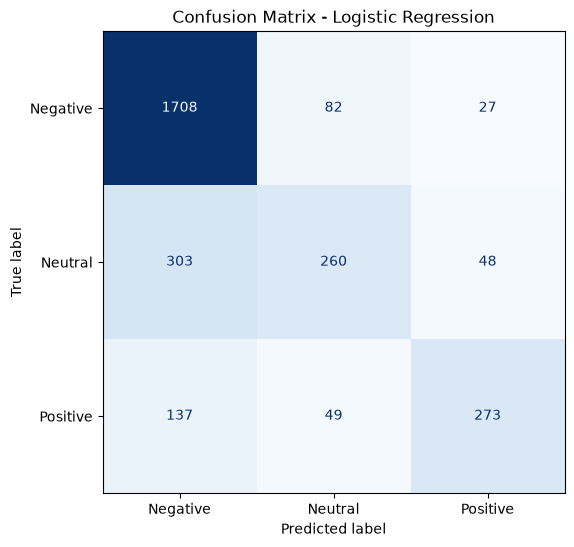

In [110]:
cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

#  Save Logistic Regression Model

The trained Logistic Regression model is saved so that it can be reused later without retraining.

This model will also be deployed in the Streamlit application if selected as the best-performing model.

In [111]:
joblib.dump(
    lr_model,
    "../models/logistic_regression_model.pkl"
)

print("✅ Logistic Regression model saved successfully.")

✅ Logistic Regression model saved successfully.


#  Save TF-IDF Vectorizer

The TF-IDF vectorizer must be saved alongside the trained model.

During prediction, incoming tweets must undergo the same TF-IDF transformation before being passed to the classifier.

In [112]:
joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

print("✅ TF-IDF Vectorizer saved successfully.")

✅ TF-IDF Vectorizer saved successfully.


#  Logistic Regression Summary

The Logistic Regression model has been successfully trained and evaluated.

The following artifacts have been generated:

- Trained Logistic Regression model
- TF-IDF Vectorizer
- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

These results will later be compared with the Multinomial Naïve Bayes classifier to determine the better-performing model.

# Multinomial Naïve Bayes

## Objective

Multinomial Naïve Bayes is a probabilistic machine learning algorithm widely used for Natural Language Processing (NLP) tasks such as spam detection and sentiment analysis.

It is particularly effective with TF-IDF and Bag-of-Words representations because it assumes word frequencies are conditionally independent.

The model will be trained using the TF-IDF feature vectors created in the previous section.

In [113]:
# Create Multinomial Naive Bayes model

nb_model = MultinomialNB()

# Train model

nb_model.fit(X_train_tfidf, y_train)

print("✅ Multinomial Naive Bayes model trained successfully.")

✅ Multinomial Naive Bayes model trained successfully.


#  Predict Test Data

The trained Multinomial Naïve Bayes classifier is used to predict the sentiment labels of unseen tweets from the testing dataset.

In [114]:
nb_predictions = nb_model.predict(X_test_tfidf)

nb_predictions[:10]

array([0, 0, 0, 0, 1, 2, 0, 2, 0, 0])

#  Evaluate Multinomial Naïve Bayes

To evaluate the classifier, we compute:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics allow us to compare Naïve Bayes with Logistic Regression.

In [115]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted"
)

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")

Accuracy  : 0.7274
Precision : 0.7307
Recall    : 0.7274
F1 Score  : 0.6797


#  Classification Report

Display the complete classification report for the Multinomial Naïve Bayes model.

In [116]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.72      0.98      0.83      1817
     Neutral       0.68      0.21      0.32       611
    Positive       0.84      0.42      0.56       459

    accuracy                           0.73      2887
   macro avg       0.75      0.54      0.57      2887
weighted avg       0.73      0.73      0.68      2887



#  Confusion Matrix

The confusion matrix illustrates how many tweets from each sentiment category were correctly and incorrectly classified by the Naïve Bayes model.

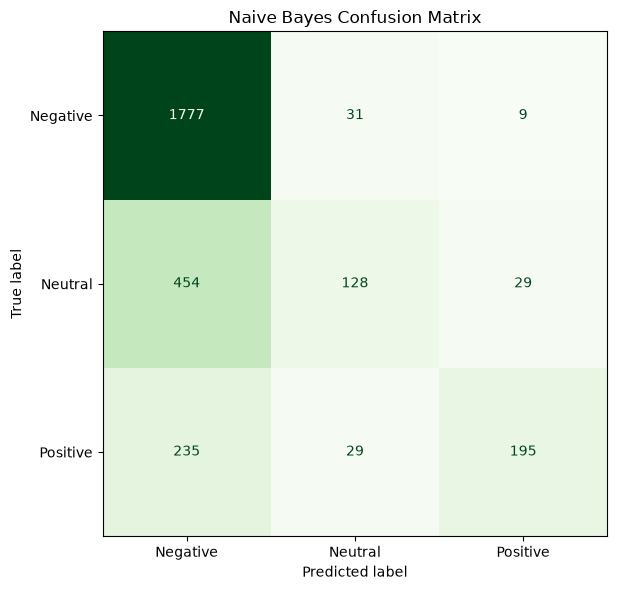

In [124]:
cm_nb = confusion_matrix(y_test, nb_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Naive Bayes Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/naive_bayes_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [118]:
joblib.dump(
    nb_model,
    "../models/naive_bayes_model.pkl"
)

print("✅ Naive Bayes model saved successfully.")

✅ Naive Bayes model saved successfully.


#  Model Comparison

To identify the better-performing classifier, both models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score

The model with the highest overall performance will be selected as the baseline model for deployment.

In [119]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],

    "Accuracy":[
        lr_accuracy,
        nb_accuracy
    ],

    "Precision":[
        lr_precision,
        nb_precision
    ],

    "Recall":[
        lr_recall,
        nb_recall
    ],

    "F1 Score":[
        lr_f1,
        nb_f1
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.776238,0.765906,0.776238,0.759630
1,Multinomial Naive Bayes,0.727399,0.730680,0.727399,0.679661


#  Best Performing Model

Determine which classifier achieved the highest accuracy and select it as the baseline model.

In [120]:
best_model_name = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


#  Save the Best Model

The best-performing classifier is exported as the final baseline model.
This model will be reused during deployment.

In [121]:
if lr_accuracy >= nb_accuracy:

    best_model = lr_model

else:

    best_model = nb_model

joblib.dump(
    best_model,
    "../models/best_classical_model.pkl"
)

print("✅ Best classical model saved.")

✅ Best classical model saved.


#  Performance Visualization

The comparison chart provides a visual representation of the accuracy achieved by the two classifiers.

In [5]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "LSTM"
    ],
    "Accuracy": [
        0.78,
        0.73,
        0.78   # Replace with your actual final LSTM accuracy if different
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.78
1,Naive Bayes,0.73
2,LSTM,0.78


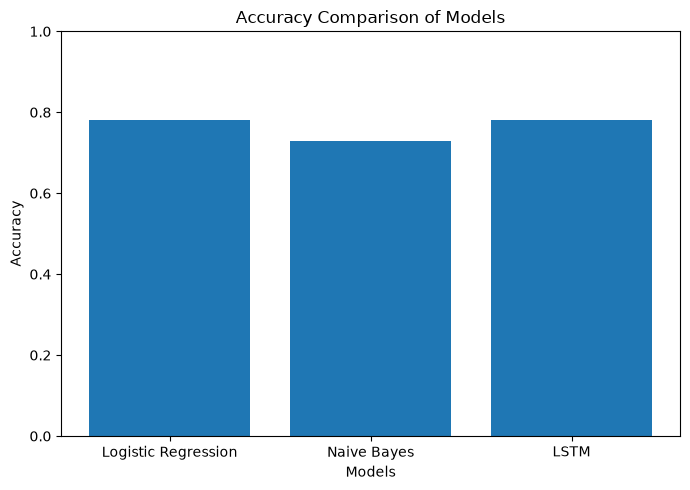

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Accuracy Comparison of Models")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    "../images/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ✅ Week 2 Summary

## Tasks Completed

✔ Label Encoding

✔ Train-Test Split

✔ TF-IDF Vectorization

✔ Logistic Regression Training

✔ Logistic Regression Evaluation

✔ Multinomial Naïve Bayes Training

✔ Multinomial Naïve Bayes Evaluation

✔ Classification Reports

✔ Confusion Matrices

✔ Model Comparison

✔ Saved:
- Logistic Regression Model
- Naïve Bayes Model
- TF-IDF Vectorizer
- Best Classical Model

---

## Outcome

The Classical NLP pipeline has been successfully implemented.

The project now contains a complete machine learning workflow for sentiment classification using traditional NLP techniques.